In [1]:
%pip install torch torchvision pennylane matplotlib scikit-learn pandas seaborn tqdm

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached rustworkx-0.17.1-cp39-abi3-win_amd64.whl.metadata (10 kB)
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached appdirs-1.4.4-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached cachetools-7.0.5-py3-none-any.whl.metadata (5.6 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached tomlkit-0.14.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached scipy_openblas32-0.3.31.188.0-py3-no

Could not find platform independent libraries <prefix>


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import pennylane as qml

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [6]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 5
LR = 1e-3
N_QUBITS = 4
N_Q_LAYERS = 2
torch.manual_seed(SEED)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=4, n_layers=2):
        super().__init__()
        dev = qml.device('default.qubit', wires=n_qubits)

        @qml.qnode(dev, interface='torch')
        def circuit(inputs, weights):
            for i in range(n_qubits):
                qml.RY(inputs[..., i], wires=i)
            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RX(weights[l][i], wires=i)
                    qml.RZ(weights[l][i], wires=i)
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.layer = qml.qnn.TorchLayer(circuit, {'weights': (n_layers, n_qubits)})

    def forward(self, x):
        return self.layer(x)

class QSANNClassifier(nn.Module):
    def __init__(self, n_qubits=4, n_q_layers=2, num_classes=10):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
        )
        self.reducer = nn.Linear(32 * 7 * 7, n_qubits)
        self.quantum = QuantumLayer(n_qubits=n_qubits, n_layers=n_q_layers)
        self.classifier = nn.Linear(n_qubits, num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.reducer(x)
        x = self.quantum(x)
        return self.classifier(x)

model = QSANNClassifier(n_qubits=N_QUBITS, n_q_layers=N_Q_LAYERS).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [8]:
def train_model(model, train_loader, test_loader, epochs):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        running_loss, n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            n += x.size(0)
        train_loss = running_loss / n

        model.eval()
        vloss, correct, m = 0.0, 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                vloss += loss.item() * x.size(0)
                correct += (logits.argmax(dim=1) == y).sum().item()
                m += x.size(0)
        val_loss = vloss / m
        val_acc = correct / m
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'Epoch {epoch+1}/{epochs} - train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}')

    train_time = time.perf_counter() - start
    gpu_mem_mb = torch.cuda.max_memory_allocated() / (1024**2) if device.type == 'cuda' else 0.0
    return history, train_time, gpu_mem_mb

history, train_time_sec, gpu_memory_mb = train_model(model, train_loader, test_loader, EPOCHS)

Epoch 1/5 - train_loss=1.6257 val_loss=1.2853 val_acc=0.5091
Epoch 2/5 - train_loss=1.0912 val_loss=0.8604 val_acc=0.8116
Epoch 3/5 - train_loss=0.6634 val_loss=0.5178 val_acc=0.9474
Epoch 4/5 - train_loss=0.4019 val_loss=0.3353 val_acc=0.9599
Epoch 5/5 - train_loss=0.2681 val_loss=0.2407 val_acc=0.9625


,model,accuracy,precision,recall,f1,training_time_sec,gpu_memory_mb,num_parameters,inference_time_per_sample_sec
0,QSANN,0.9625,0.963211,0.9625,0.962613,588.066138,0.0,11134,0.000665


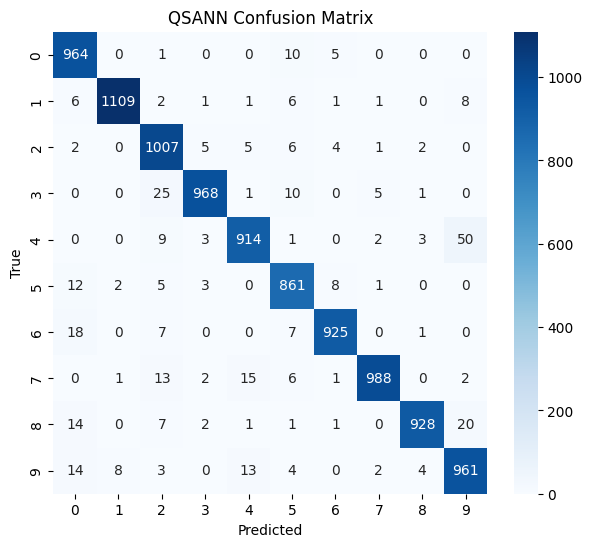

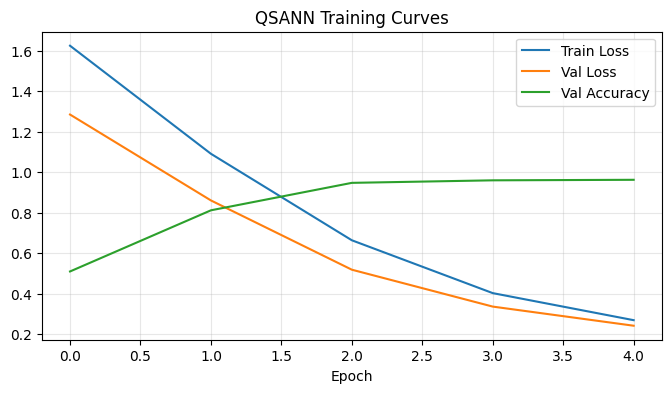

In [10]:
def predict(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1).cpu().numpy()
            y_pred.extend(pred.tolist())
            y_true.extend(y.numpy().tolist())
    return np.array(y_true), np.array(y_pred)

def inference_time_per_sample(model, loader):
    model.eval()
    t0 = time.perf_counter()
    total = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            _ = model(x)
            total += x.size(0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    return dt / max(total, 1)

y_true, y_pred = predict(model, test_loader)
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
metrics_df = pd.DataFrame([{
    'model': 'QSANN',
    'accuracy': acc,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'training_time_sec': train_time_sec,
    'gpu_memory_mb': gpu_memory_mb,
    'num_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad),
    'inference_time_per_sample_sec': inference_time_per_sample(model, test_loader),
}])
display(metrics_df)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('QSANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('QSANN Training Curves')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.show()